In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/GENs')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


import the necessary packages

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision

from MNIST import MNIST

inspect the image data

In [5]:
def imshow(image_tensors):
  # make a 8x8 grid image
  grid_image = torchvision.utils.make_grid(image_tensors)

  # show the image
  plt.figure(figsize=(6,6))
  plt.imshow(grid_image.permute(1,2,0))
  plt.axis("off")
  plt.show()

declare the LeNet CNN model for discriminator

In [6]:
class Discriminator(torch.nn.Module):
  def __init__(self):
    super(Discriminator, self).__init__()

    # two convolution layers
    self.conv_1 = torch.nn.Conv2d(in_channels=1, out_channels=6,
            kernel_size=5, stride=1, padding=2, bias=False)
    self.conv_2 = torch.nn.Conv2d(in_channels=6, out_channels=16,
            kernel_size=5, stride=1, padding=0, bias=False)

    # three fully connected layers
    self.fc_1 = torch.nn.Linear(5*5*16, 120, bias=True)
    self.fc_2 = torch.nn.Linear(120, 84, bias=True)
    self.fc_3 = torch.nn.Linear(84, 1, bias=True) # real /fake

    self.dropout = torch.nn.Dropout(0.4)
  '''
  forward(): forward pass
    received:
      x: input image [N, 1, 28, 28]

    return: [N]
  '''
  def forward(self, x):
    # [N, 1, 28, 28] --> [N, 1, 32, 32] --> [N, 6, 28, 28]
    x = torch.nn.functional.relu(self.conv_1(x))

    # [N, 6, 28, 28] --> [N, 6, 14, 14]
    x = torch.nn.functional.max_pool2d(x, kernel_size=2)

    # [N, 6, 14, 14] --> [N, 16, 10, 10]
    x = torch.nn.functional.relu(self.conv_2(x))

    # [N, 16, 10, 10] --> [N, 16, 5, 5]
    x = torch.nn.functional.max_pool2d(x, kernel_size=2)

    # flatten [N, 400]
    x = x.view(-1, 16*5*5)

    # [N, 400] --> [N, 120]
    x = torch.nn.functional.relu(self.fc_1(x))
    #x = self.dropout(x)

    # [N, 120] --> [N, 84]
    x = torch.nn.functional.relu(self.fc_2(x))
    #x = self.dropout(x)

    # [N, 84] --> [N, 1]
    # real probability
    x = self.fc_3(x)

    # squeeze the x
    x = x.view(-1)

    return x

declare CNN model for generator

In [7]:
class Generator(torch.nn.Module):
  def __init__(self, in_dim):
    super(Generator, self).__init__()
    # transposed conv
    self.conv_1 = torch.nn.ConvTranspose2d(in_dim, 256, kernel_size=7, stride=1, padding=0, bias=False)
    self.conv_2 = torch.nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False)
    self.conv_3 = torch.nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False)
    self.conv_4 = torch.nn.ConvTranspose2d(64, 1, kernel_size=3, stride=1, padding=1, bias=False)

    # two batch normalization
    self.bn_1 = torch.nn.BatchNorm2d(256)
    self.bn_2 = torch.nn.BatchNorm2d(128)
    self.bn_3 = torch.nn.BatchNorm2d(64)

  '''
  forward(): forward pass
    received:
      x: noise [N, 100, 1, 1]

    return: [N, 1, 28, 28]
  '''
  def forward(self, x):
    # x: [N, z_dim, 1, 1] → [N, 256, 7, 7]
    x = torch.nn.functional.relu(self.bn_1(self.conv_1(x)))

    # x: [N, 256, 7, 7] → [N, 256, 14, 14]
    x = torch.nn.functional.relu(self.bn_2(self.conv_2(x)))

    # [N, 128, 14, 14] --> [N, 64, 28, 28]
    x = torch.nn.functional.relu(self.bn_3(self.conv_3(x)))

    # [N, 64, 28, 28] --> [N, 1, 28, 28]
    x = torch.nn.functional.sigmoid(self.conv_4(x))

    return x



hyper-parameter setting

In [8]:
n_epochs = 200
batch_size = 64

z_dim = 100 # noise dimension
h_dim = 128 # hidden dimension

D_learning_rate = 0.00005
G_learning_rate = 0.0002

load the mnist training dataset and create a dataloader

In [9]:
mnist_train = MNIST("train-images.idx3-ubyte","train-labels.idx1-ubyte")
mnist_loader = torch.utils.data.DataLoader(dataset=mnist_train, batch_size = batch_size, shuffle=True, drop_last=True)

create device CPU or GPU

In [10]:
if torch.cuda.is_available():
  device = torch.device("cuda")
else:
  device = torch.device("cpu")

define the discriminator and generator models

In [11]:
D = Discriminator().to(device)
G = Generator(z_dim).to(device)

create the optimiers for discriminator and generator

In [12]:
D_optimizer = torch.optim.Adam(D.parameters(), lr=D_learning_rate)
G_optimizer = torch.optim.Adam(G.parameters(), lr=G_learning_rate)

define the labels for real and fakes samples

In [13]:
ones_label = torch.ones(batch_size).to(device)
zeros_label = torch.zeros(batch_size).to(device)

train in adversarial manner

0:936
D loss: 1.1506190552130708
G Loss: 1.0897293278794407
1:936
D loss: 1.3920374805924731
G Loss: 0.6933124313486806
2:936
D loss: 1.390875536451472
G Loss: 0.6973691933819172
3:936
D loss: 1.387946884431096
G Loss: 0.6984592407083053
4:936
D loss: 1.3858242588338374
G Loss: 0.6974265459634705
5:936
D loss: 1.384548931645991
G Loss: 0.6954344733674854
6:936
D loss: 1.3874286396653572
G Loss: 0.6902149441148072
7:936
D loss: 1.3864223792942254
G Loss: 0.6970328880730408
8:936
D loss: 1.3856225118056942
G Loss: 0.6952718379276157
9:936
D loss: 1.3852962475576167
G Loss: 0.691687730358657


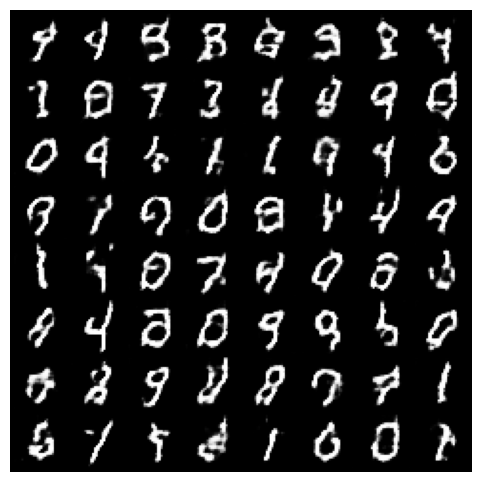

10:936
D loss: 1.385681653735223
G Loss: 0.6980563623546409
11:936
D loss: 1.386354792079905
G Loss: 0.6953484791956182
12:936
D loss: 1.386322838774104
G Loss: 0.6949310721302745
13:936
D loss: 1.3862442913024886
G Loss: 0.6933538701898133
14:936
D loss: 1.3860344774822289
G Loss: 0.6932509007805058
15:936
D loss: 1.3852939151521682
G Loss: 0.69291990015779
16:936
D loss: 1.385248211939027
G Loss: 0.694642000353578
17:936
D loss: 1.3857732956539224
G Loss: 0.6939441407121233
18:936
D loss: 1.3857383345081813
G Loss: 0.6934081546270479
19:936
D loss: 1.3855799077796325
G Loss: 0.6940634456744443


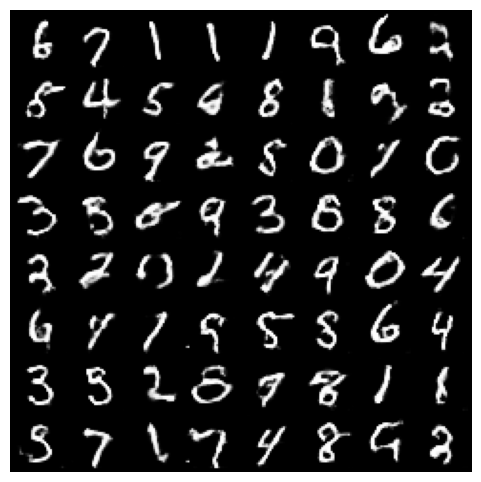

20:936
D loss: 1.3853938996855453
G Loss: 0.6942295070773382
21:936
D loss: 1.3853902517795054
G Loss: 0.6941513615076926
22:936
D loss: 1.385290648919414
G Loss: 0.6937362417467375
23:936
D loss: 1.3853078237083705
G Loss: 0.6943830504234216
24:936
D loss: 1.3852779634988677
G Loss: 0.6942997452034639
25:936
D loss: 1.3853325387075337
G Loss: 0.6931304992072228
26:936
D loss: 1.3853646677102707
G Loss: 0.6945445136810189
27:936
D loss: 1.385319430138538
G Loss: 0.6940806815311265
28:936
D loss: 1.3853028590294951
G Loss: 0.6941454391469314
29:936
D loss: 1.3852028741144446
G Loss: 0.694847796044711


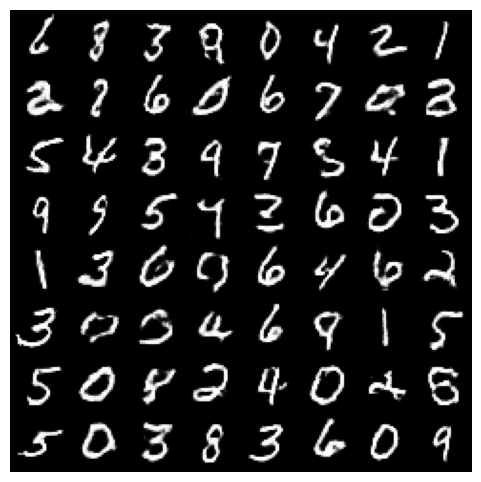

30:936
D loss: 1.3847376923678143
G Loss: 0.6944159164372732
31:936
D loss: 1.3849298008732505
G Loss: 0.6951481718391085
32:936
D loss: 1.3844862762866432
G Loss: 0.6936609120353691
33:936
D loss: 1.3844038882912033
G Loss: 0.6956705073791227
34:936
D loss: 1.3840033605996929
G Loss: 0.6944687790142943
35:936
D loss: 1.3840404843062704
G Loss: 0.6952443680106767
36:936
D loss: 1.3839134948612404
G Loss: 0.6951762517971825
37:936
D loss: 1.3837736145282122
G Loss: 0.6956470681229167
38:936
D loss: 1.3838536906013366
G Loss: 0.6953184575383157
39:936
D loss: 1.383588959338698
G Loss: 0.6958404925106175


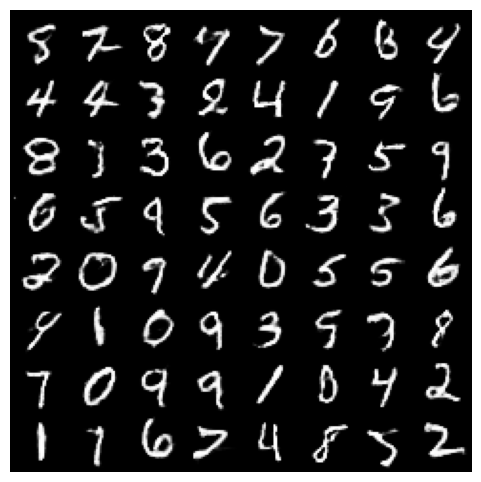

40:936
D loss: 1.3837013665741764
G Loss: 0.6960132603584257
41:936
D loss: 1.3834724902088893
G Loss: 0.69577692934136
42:936
D loss: 1.3831358354145078
G Loss: 0.6957246947441182
43:936
D loss: 1.383220604415128
G Loss: 0.6956575554233987
44:936
D loss: 1.3830145027492446
G Loss: 0.6947056137764849
45:936
D loss: 1.382988379884555
G Loss: 0.6974590317035052
46:936
D loss: 1.3829493018835306
G Loss: 0.6964311017679685
47:936
D loss: 1.3821546810032082
G Loss: 0.6963236026601068
48:936
D loss: 1.3822323508807155
G Loss: 0.6961338817755212
49:271

In [ ]:
# define loss function
bce_loss = torch.nn.BCEWithLogitsLoss()

loss_history = []

for epoch in range(n_epochs):
  # init batch = 0
  batch = 0
  D_total_loss = 0
  G_total_loss = 0

  for x_reals, y_labels in mnist_loader:
    print(f'\r{epoch}:{batch}',end='')
    # put the data to device
    x_reals = x_reals.to(device)

    # use generator to produce the fake images
    z_noises = torch.randn(batch_size, z_dim, 1, 1).to(device)
    x_fakes = G(z_noises).detach()

    # --- train discriminator ---
    # Freeze G, enable D
    for p in G.parameters(): p.requires_grad = False
    for p in D.parameters(): p.requires_grad = True

    # forward pass
    y_reals = D(x_reals)
    y_fakes = D(x_fakes)

    # backward pass
    D_loss = bce_loss(y_reals, ones_label) \
        + bce_loss(y_fakes, zeros_label)
    D_total_loss += D_loss.item()

    D_optimizer.zero_grad()
    D_loss.backward()
    D_optimizer.step()

    # --- train generator ---
    # Freeze D, enable G
    for p in D.parameters(): p.requires_grad = False
    for p in G.parameters(): p.requires_grad = True

    # forward pass
    z_noises = torch.randn(batch_size, z_dim, 1, 1).to(device)
    x_fakes = G(z_noises)
    y_fakes = D(x_fakes)

    # backward pass
    G_loss = bce_loss(y_fakes, ones_label)
    G_total_loss += G_loss.item()

    G_optimizer.zero_grad()
    G_loss.backward()
    G_optimizer.step()

    # increase the batch
    batch = batch + 1

  # show the generated images per 10 epoches
  D_average_loss = D_total_loss / batch
  G_average_loss = G_total_loss / batch
  print(f'\nD loss: {D_average_loss}')
  print(f'G Loss: {G_average_loss}')
  loss_history.append((D_average_loss, G_average_loss))

  if (epoch+1) % 10 == 0:
    z_noises = torch.randn(batch_size, z_dim, 1, 1).to(device)
    x_fakes = G(z_noises)
    imshow(x_fakes.detach().cpu())

# draw the loss curves
plt.plot(range(len(loss_history)), [x[0] for x in loss_history], label="D loss")
plt.plot(range(len(loss_history)), [x[1] for x in loss_history], label="G loss")

